# Chapter 19 — Optimizing Data Skewness and Spillage (Salting Technique)

In this chapter, we explore **Data Skewness** and **Memory Spillage** during joins, analyze Spark UI metrics to detect skewed partitions and disk spillage, and learn how to optimize skewed workloads using the **Salting Technique**.

---

In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder.appName("OptimizingSkewnessAndSpillage")
        .master("spark://4619b568af8b:7077")
        .config("spark.executor.cores",4)
        .config("spark.cores.max",8)
        .config("spark.executor.memmory","512M")
        .getOrCreate()
        )
spark

In [2]:
# Disable AQE and Broadcast join
spark.conf.set("spark.sql.adaptive.enabled", False)
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", False)
spark.conf.set("spark.sql.autoBroadcastJoinThreshold", -1)

#### ☝️ Why We Disable AQE and Broadcast Join for This Experiment

In a production Spark 3+ cluster, two automatic optimizations normally prevent or hide data skew:
1. **Broadcast Hash Join (BHJ):** Because `dept` is small (10 rows), Spark's `autoBroadcastJoinThreshold` (default 10 MB) would automatically broadcast `dept` to all executors. A broadcast join requires **no shuffle**, so partition skew would never happen.
2. **Adaptive Query Execution (AQE):** When enabled (`spark.sql.adaptive.enabled = True`), Spark 3+ automatically detects skewed shuffle partitions at runtime (`spark.sql.adaptive.skewJoin.enabled`) and splits them into smaller sub-partitions.

By setting `autoBroadcastJoinThreshold = -1` and disabling AQE, we force Spark to perform a standard **SortMergeJoin with full shuffle** — allowing us to study the raw mechanics of data skewness, memory spillage, and salting from first principles.

---

In [3]:
# Read Employee data
_schema = "first_name string, last_name string, job_title string, dob string, email string, phone string, salary double, department_id int"
emp = spark.read.format("csv").schema(_schema).option("header", True).load("/data/csv/employee_records.csv")

In [4]:
# Read DEPT CSV data
_dept_schema = "department_id int, department_name string, description string, city string, state string, country string"
dept = spark.read.format("csv").schema(_dept_schema).option("header", True).load("/data/csv/department_data.csv")

In [5]:
# Join Datasets
'''SELECT * FROM emp LEFT OUTER JOIN dept ON emp.department_id = dept.department_id'''
df_joined = emp.join(dept, on=emp.department_id==dept.department_id, how="left_outer")
df_joined.write.format("noop").mode("overwrite").save()
df_joined.explain()

== Physical Plan ==
*(4) SortMergeJoin [department_id#7], [department_id#16], LeftOuter
:- *(1) Sort [department_id#7 ASC NULLS FIRST], false, 0
:  +- Exchange hashpartitioning(department_id#7, 200), ENSURE_REQUIREMENTS, [id=#70]
:     +- FileScan csv [first_name#0,last_name#1,job_title#2,dob#3,email#4,phone#5,salary#6,department_id#7] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/data/csv/employee_records.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<first_name:string,last_name:string,job_title:string,dob:string,email:string,phone:string,s...
+- *(3) Sort [department_id#16 ASC NULLS FIRST], false, 0
   +- Exchange hashpartitioning(department_id#16, 200), ENSURE_REQUIREMENTS, [id=#82]
      +- *(2) Filter isnotnull(department_id#16)
         +- FileScan csv [department_id#16,department_name#17,description#18,city#19,state#20,country#21] Batched: false, DataFilters: [isnotnull(department_id#16)], Format: CSV, Location: InMem

## 📝 Understanding Data Skewness & Memory Spillage in Spark UI

### 1. Observations from the Spark UI

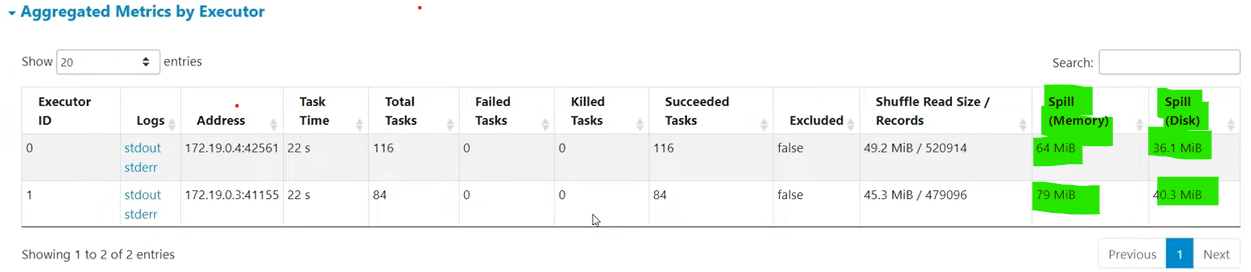

#### ☝️ Observation 1 — Spill (Memory) and Spill (Disk) Have Appeared
In the **Summary Metrics** table above, we can now see two new metrics that were previously hidden:
- **Spill (Memory):** `~79.0 MiB`
- **Spill (Disk):** `~40.3 MiB`

Recall that the Spark UI **only displays spill metrics when actual data spillage occurs**. Here, memory limits were exceeded during the `SortMergeJoin`, forcing Spark to write excess data to disk.

---

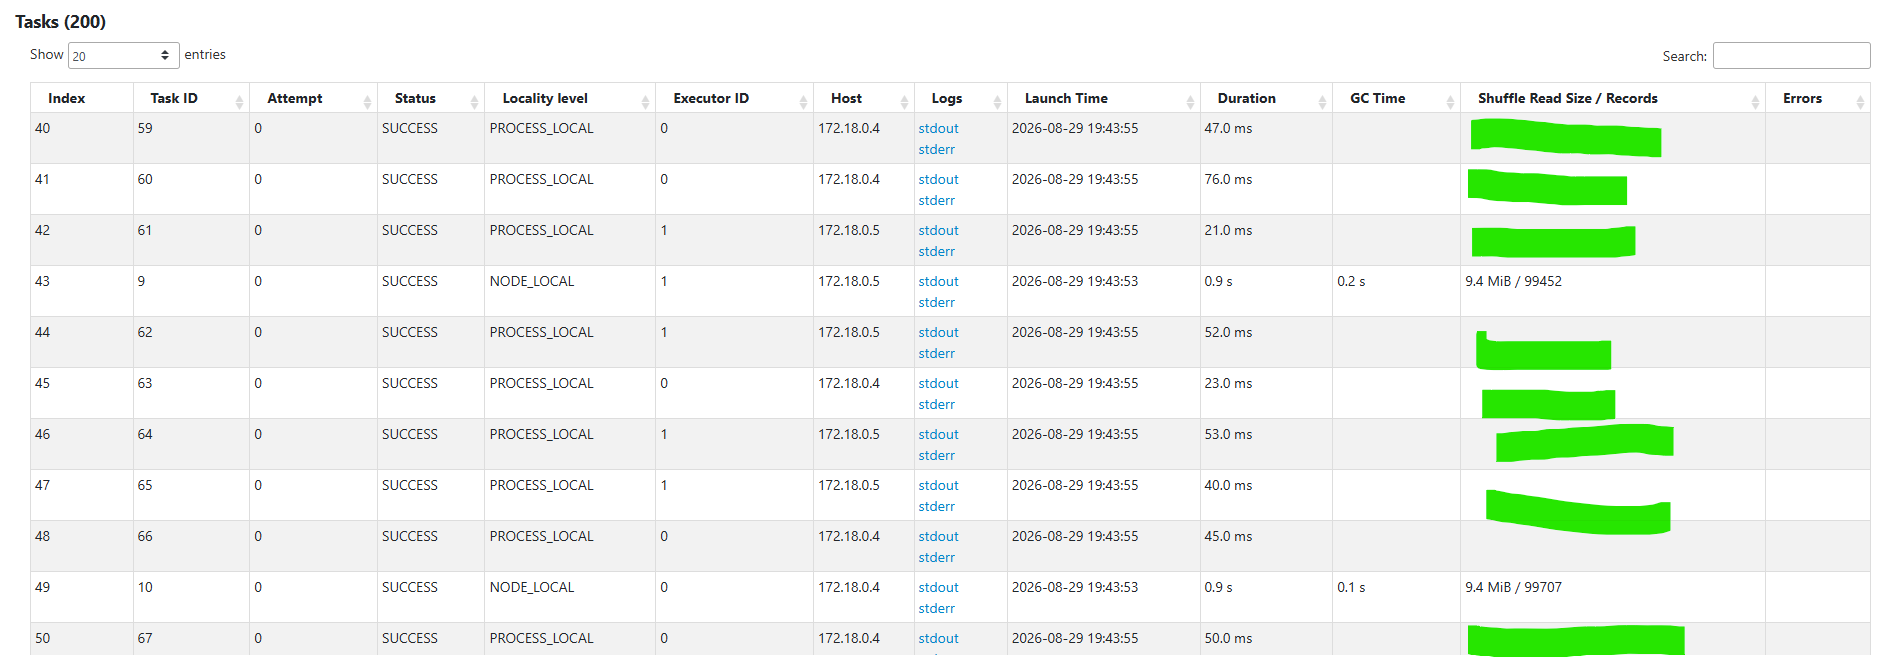

#### ☝️ Observation 2 — Uneven Task Workload (200 Partitions Inefficiency)
Looking at the **Tasks (200)** table:
- Out of **200 shuffle tasks**, only a couple of tasks processed almost all the data, while the vast majority processed **0 B / 0 records**.
- Having `200` shuffle partitions when only a few keys have data is wasteful because Spark creates and schedules 200 separate tasks across executors for almost no work on 190+ of them.

---

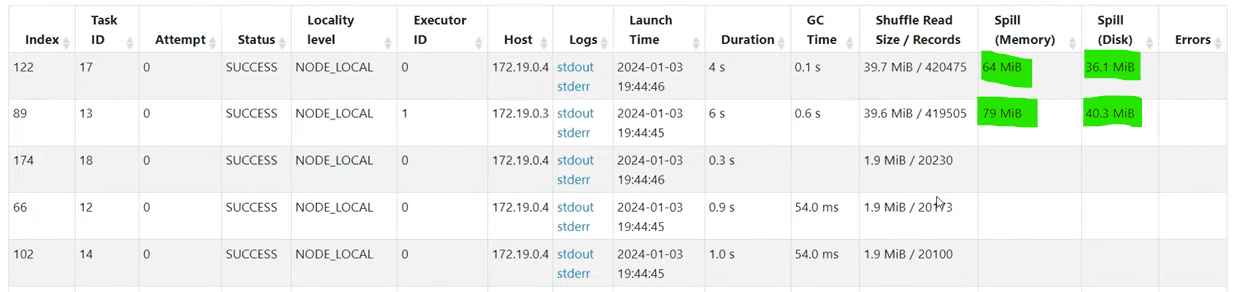

#### ☝️ Observation 3 — Overloaded Straggler Tasks Processing Huge Volumes
- A few specific tasks are processing **over 400,000 records (4 Lakh rows)** in a single partition!
- These overloaded tasks take significantly longer to finish than the others (**straggler tasks**), and because they hold so much data simultaneously, they cause the **memory spillage**.

---

### 2. The Core Mechanism: How Data Skewness Causes Spillage

**Data Skewness and Memory Spillage go hand in hand.**

1. **What is Data Skewness?**
   - In our join, the joining key is `department_id`.
   - In a balanced dataset, employees are evenly spread across departments.
   - In a **skewed dataset**, a few `department_id` values have significantly more records than others (for example, 400,000+ employees in one department vs. only 10 in another).
   - Because Spark hashes the join key (`hash(department_id) % 200`), all rows with the exact same `department_id` are forced onto the **same partition** on a single executor.

2. **What is Memory Spillage (Spill to Disk)?**
   - An executor has a fixed JVM execution memory pool (e.g., a fraction of its total 512 MB memory).
   - When that single executor tries to sort and join 400,000+ records for the skewed department, the data exceeds the available execution memory buffer in RAM.
   - Spark cannot hold all those records in memory at once, so it **spills** (writes) the overflow data to the executor's local hard disk.

3. **What Do the Spill Metrics Mean?**
   - **Spill (Memory) — ~79.0 MiB:** The size of the data in RAM as uncompressed, deserialized Java objects.
   - **Spill (Disk) — ~40.3 MiB:** The size of that same data after Spark serializes and compresses it to write it to local disk.

4. **Why Spillage Destroys Performance:**
   - Spark is designed for in-memory computation (RAM speed).
   - When data spills to disk, Spark must write the spilled data to disk, read it back via disk I/O, and deserialize it before continuing. Disk I/O is hundreds of times slower than RAM!
   - The entire query gets stuck waiting for that one straggler task to finish its disk read/write cycles.

> **💡 Key Takeaway:** To eliminate spillage and fix the job bottleneck, we must fix the root cause — **Data Skewness**. Next, we will learn how to evenly distribute skewed keys across multiple partitions using the **Salting Technique**.

---

In [6]:
# Checking partition details to understand row distribution
'''SELECT spark_partition_id() AS partition_num, COUNT(1) AS count FROM df_joined GROUP BY spark_partition_id()'''
from pyspark.sql.functions import spark_partition_id, count, lit
part_df = df_joined.withColumn("partition_num", spark_partition_id()).groupBy("partition_num").agg(count(lit(1)).alias("count"))
part_df.show()

+-------------+------+
|partition_num| count|
+-------------+------+
|          103|100417|
|          122| 99780|
|           43| 99451|
|          107| 99805|
|           49| 99706|
|           51|100248|
|          102|100214|
|           66|100210|
|          174|100155|
|           89|100014|
+-------------+------+



#### ☝️ Why We Pass `lit(1)` to `count()` — Understanding Literal Values

In the cell above, we used `spark_partition_id()` and `count(lit(1))` to inspect how rows are distributed across partitions.

**1. What is `lit(1)`?**
`lit` stands for **literal** (a constant value). PySpark aggregation functions expect a `Column` object rather than a plain Python integer `1`. Calling `lit(1)` creates a temporary column where every single row has the non-null value `1`.

**2. Why pass `lit(1)` instead of a column name?**
In SQL and PySpark, counting a specific column behaves differently from counting a constant:
- `count("department_name")` *(SQL: `COUNT(department_name)`)*: ⚠️ **Skips `null` values!** Because our left outer join produces `null` values for unmatched departments, those rows would be ignored.
- `count(lit(1))` *(SQL: `COUNT(1)`)*: ✅ **Counts every single row**, because `1` is never `null`.
- `count("*")` *(SQL: `COUNT(*)`)*: ✅ Also counts every single row.

**3. What This Output Reveals:**
When you run `.show()`, you can programmatically confirm what the Spark UI showed us:
- Most partitions have count `0` or very small counts.
- The skewed partitions hold **400,000+ records**, proving that data is severely concentrated in just a few partition IDs.

---

#### ☝️ Observation — Severe Partition Imbalance (Only 10 of 200 Partitions Have Data)

> **User Observation:**
> *If you notice some of the partitions having large number of tasks to perform, example: partition 103 has 100,417 rows. Out of 200 shuffle partitions, only 10 have data and 190 are empty.*

**Why does this happen?**
- In our dataset, there are only **10 distinct departments** (`department_id` 1 to 10).
- Spark's default hash partitioner computes: `partition_index = hash(department_id) % 200`.
- Because there are only 10 unique department keys, Spark maps all 1 million employee rows into **only 10 specific partition buckets**.
- The remaining **190 partitions get 0 rows**, but Spark still creates empty shuffle tasks for them — a waste of scheduling overhead.
- Worse, the 10 partitions that *do* receive data are heavily overloaded with ~100,000 rows each.

---

In [7]:
# to verify which emp  department_id is causing the spilling
from pyspark.sql.functions import count,lit,desc,col
emp.groupBy("department_id").agg(count(lit(1))).show()

            # here see these are having 1 lakh data in this department_id's
            # 3|  100248|
            # 5|  100210|
            # 9|  100014|
            # 4|  100214|
            # 8|  100417|
            # 2|  100155|


+-------------+--------+
|department_id|count(1)|
+-------------+--------+
|            1|   99451|
|            6|   99706|
|            3|  100248|
|            5|  100210|
|            9|  100014|
|            4|  100214|
|            8|  100417|
|            7|   99805|
|           10|   99780|
|            2|  100155|
+-------------+--------+



#### ☝️ Verifying the Heavy Keys Causing the Skew

When we group `emp` by `department_id`, the output confirms the root cause of our skew:
- Departments `3, 5, 9, 4, 8` each contain **over 100,000 records (1 Lakh rows)**.
- When joining `emp` and `dept` on `department_id`, all 100,000+ records for Department 3 are sent to the same single task on one executor.
- That single executor task must sort and hold all 100,000+ records in its execution memory buffer, exhausting RAM and triggering the **~79 MiB memory spill** to disk.

---

## 📝 2. So Repartitioning Is the Solution, But Even If We Repartition, `department_id` Is the Same Right? So They Will Come Back to the Same Task.

### 👉 SO TO FIX WE CAN USE SALTING!

**Why does plain repartitioning fail? Because all rows with the same `department_id` produce the exact same hash value and land in the same task. To break that clump apart, we use Salting.**

```text
┌──────────────────────────────────────────────────────────────────┐
│              STEP 1: ORIGINAL DATA BEFORE SALTING                │
├──────────────────────────────────────────────────────────────────┤
│                                                                  │
│  EMPLOYEE (Fact Table)                DEPARTMENT (Dim Table)     │
│  department_id                        department_id              │
│  ─────────────                        ─────────────              │
│       1                                    1                     │
│       1                                    2                     │
│       1                                    3                     │
│       2                                                          │
│     ┌───┐                                                        │
│     │ 3 │ \                                                      │
│     │ 3 │  |                                                     │
│     │ 3 │  | ---> HERE IS THE SKEW!                              │
│     │ 3 │  |      (5 rows out of 9 total land in 1 task!)        │
│     │ 3 │ /                                                      │
│     └───┘                                                        │
│                                                                  │
│  Without Salting: Task for dept 3 is overloaded ---> SPILL!      │
│                                                                  │
├──────────────────────────────────────────────────────────────────┤
│              STEP 2: APPLYING SALTING (SALT RANGE: 0, 1)         │
├──────────────────────────────────────────────────────────────────┤
│                                                                  │
│  EMPLOYEE (Add Random 0 or 1)         DEPARTMENT (Replicate 0, 1)│
│  dept_id + Random(0, 1)               dept_id Replicated (3x2=6) │
│  ──────────────────────               ────────────────────────── │
│   1_1                                  1_0                       │
│   1_0                                  2_0                       │
│   1_1                             ┌──> ┌─────┐                   │
│   2_0                             │    │ 3_0 │ (Salt 0 Block)    │
│  ┌─────────┐                      │    └─────┘                   │
│  │ 3_1     │                      │    1_1                       │
│  │ 3_1     │ (2 rows) ────┐       │    2_1                       │
│  └─────────┘              │       │ ┌> ┌─────┐                   │
│  ┌─────────┐              │       │ │  │ 3_1 │ (Salt 1 Block)    │
│  │ 3_0     │              │       │ │  └─────┘                   │
│  │ 3_0     │ (3 rows) ────│───────┘ │                            │
│  │ 3_0     │              │         │                            │
│  └─────────┘              └─────────┘                            │
│                                                                  │
├──────────────────────────────────────────────────────────────────┤
│              STEP 3: AFTER SALTING (PARALLEL JOIN)               │
├──────────────────────────────────────────────────────────────────┤
│                                                                  │
│  - Task A (Partition A): Joins "3_1" (2 rows) with "3_1"         │
│  - Task B (Partition B): Joins "3_0" (3 rows) with "3_0"         │
│                                                                  │
│  - Step 4: Drop/Remove the temporary salt column!                │
│                                                                  │
└──────────────────────────────────────────────────────────────────┘
```

The entire before-and-after story, walked through step-by-step:

### 1. Before Salting — Spotting the Skew
Look at the raw Employee table on the left:
```text
1
1
1
2
3 ┐
3 │
3 ├─ HERE WE HAVE SEVERE SKEWING! (5 out of 9 rows belong to dept 3)
3 │
3 ┘
```
- In a normal join, Spark computes `hash(department_id) % 200`.
- Because all five rows have `department_id = 3`, they all get the **exact same hash value**.
- Even if you call `.repartition(200)`, Spark is forced to put all rows of `3` into the **same single task** on one executor.
- That single executor runs out of memory trying to process the entire skewed workload and **spills to disk**.

---

### 2. The Salting Solution — Breaking Up the Clump
To fix this, we introduce **Salting** using a salt range `[0, 1]`:

1. **In the Employee (Fact) Table:**
   - We assign a random number (`0` or `1`) to each employee row and concatenate it: `department_id_salt`.
   - The five rows of `3` get randomly split into:
     - **`3_1`** (2 rows)
     - **`3_0`** (3 rows)
2. **In the Department (Dimension) Table:**
   - The Department table only has 3 rows (`1, 2, 3`).
   - Because an employee row could have been salted with `0` OR `1`, we must replicate (explode) the Department table for every salt value `[0, 1]` ((3 departments x 2 = 6 rows)):
     - `1_0, 2_0, 3_0` (salt 0 block)
     - `1_1, 2_1, 3_1` (salt 1 block)

---

### 3. After Salting — True Parallel Execution
Now we join on the new salted key **`salted_dept_id`**:
- The 2 rows with `3_1` join with `Department(3_1)` in **Task A**.
- The 3 rows with `3_0` join with `Department(3_0)` in **Task B**.
- Because `hash("3_1") != hash("3_0")`, the heavy workload for department 3 is **split across 2 separate parallel tasks and 2 CPU cores**.
- No task is overloaded, and **memory spillage is completely eliminated**!

---

### 4. Cleanup — Dropping the Salt Column
Once the join is complete, we call `.drop("salt", "salted_dept_id")`. The final DataFrame has the exact same clean schema as a standard join, but executed at full cluster speed.

---

In [25]:
# Set shuffle partitions to a lesser number - 32
spark.conf.set("spark.sql.shuffle.partitions", 32)

#### ☝️ Setting `spark.sql.shuffle.partitions` to 32

We reduced `spark.sql.shuffle.partitions` from `200` to `32`:
- In our cluster setup, we have 8 executor cores (`spark.cores.max = 8`).
- 200 partitions created 190 empty tasks.
- 32 partitions matches our salt range (`0` to `31`), giving exactly 4 balanced tasks per CPU core with zero empty partitions.

---

In [26]:
# Let prepare the salt
import random
from pyspark.sql.functions import udf
# UDF to return a random number every time and add to Employee as salt
@udf
def salt_udf():
    return random.randint(0,32)

# Salt Data Frame to add to department
salt_df = spark.range(0, 32)
salt_df.show()


+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
| 10|
| 11|
| 12|
| 13|
| 14|
| 15|
| 16|
| 17|
| 18|
| 19|
+---+
only showing top 20 rows



#### ☝️ Preparing the Salt — UDF and the Range Upper-Bound Nuance

In this step, we prepare two components for the salting technique:
1. **`salt_udf()`:** A Python User Defined Function that returns a random integer. When applied to `emp`, it randomly assigns a number to each employee row.
2. **`salt_df = spark.range(0, 32)`:** A DataFrame containing all possible salt values (`0, 1, 2, ..., 31`).

> [!TIP]
> **💡 Important PySpark Note: `random.randint` vs. `spark.range`**
> - `random.randint(0, 32)` in Python is **inclusive** on both ends (`0` through `32` = 33 possible values).
> - `spark.range(0, 32)` generates integers from `0` up to `31` (**exclusive** of `32` = 32 values).
> - If an employee gets salt `32`, it will not find `32` in `salt_df` and produce `null` in a left outer join.
> - To ensure 100% of employee rows match, keep the upper bound aligned: use `random.randint(0, 31)` or `random.randrange(0, 32)` with `spark.range(0, 32)`.

---

In [27]:
# Salted Employee
from pyspark.sql.functions import lit, concat
salted_emp = emp.withColumn("salted_dept_id", concat("department_id", lit("_"), salt_udf()))
salted_emp.show()

+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------+
|first_name| last_name|           job_title|       dob|               email|               phone|  salary|department_id|salted_dept_id|
+----------+----------+--------------------+----------+--------------------+--------------------+--------+-------------+--------------+
|   Richard|  Morrison|Public relations ...|1973-05-05|melissagarcia@exa...|       (699)525-4827|512653.0|            8|          8_23|
|     Bobby|  Mccarthy|   Barrister's clerk|1974-04-25|   llara@example.net|  (750)846-1602x7458|999836.0|            7|          7_24|
|    Dennis|    Norman|Land/geomatics su...|1990-06-24| jturner@example.net|    873.820.0518x825|131900.0|           10|          10_1|
|      John|    Monroe|        Retail buyer|1968-06-16|  erik33@example.net|    820-813-0557x624|485506.0|            1|          1_22|
|  Michelle|   Elliott|      Air cabin crew|1975

#### ☝️ Adding the Salt to the Skewed Employee Table

Calling `concat("department_id", lit("_"), salt_udf())` attaches a random salt suffix to every employee's `department_id`:
- **Before salting:** All 100,000 employees in Department 1 had the exact same join key: `1`.
- **After salting:** The 100,000 employees are now divided among keys `1_0`, `1_1`, `1_2`, ..., `1_31` (~3,125 rows per key).
- Because each salted key (`1_0`, `1_1`, etc.) produces a different hash value, Spark will shuffle them into **different partitions**, breaking the single-partition bottleneck!

---

In [28]:
# Salted Department
salted_dept = dept.join(salt_df, how="cross").withColumn("salted_dept_id", concat("department_id", lit("_"), "id"))
salted_dept.show()


+-------------+--------------------+--------------------+-------------+-----+-------------------+---+--------------+
|department_id|     department_name|         description|         city|state|            country| id|salted_dept_id|
+-------------+--------------------+--------------------+-------------+-----+-------------------+---+--------------+
|            1|         Bryan-James|Optimized disinte...| Melissaburgh|   FM|Trinidad and Tobago|  0|           1_0|
|            1|         Bryan-James|Optimized disinte...| Melissaburgh|   FM|Trinidad and Tobago|  1|           1_1|
|            1|         Bryan-James|Optimized disinte...| Melissaburgh|   FM|Trinidad and Tobago|  2|           1_2|
|            1|         Bryan-James|Optimized disinte...| Melissaburgh|   FM|Trinidad and Tobago|  3|           1_3|
|            2|Smith, Craig and ...|Digitized empower...|   Morrisside|   DE|          Sri Lanka|  0|           2_0|
|            2|Smith, Craig and ...|Digitized empower...|   Morr

#### ☝️ What just happened — Replicating every department with a Cross Join (Cartesian Product)

A **Cartesian Product (Cross Join)** pairs **every single row** of `dept` with **every single row** of `salt_df`.

```text
1. BEFORE: dept (10 rows) and salt_df (32 rows)
   dept                       salt_df
   ┌───────────────┬────────┐ ┌────┐
   │ department_id │ name   │ │ id │
   ├───────────────┼────────┤ ├────┤
   │ 1             │ Bryan  │ │ 0  │
   │ 2             │ Smith  │ │ 1  │
   │ ...           │ ...    │ │ .. │
   │ 10            │ Keller │ │ 31 │
   └───────────────┴────────┘ └────┘

2. TRANSFORMATION: Cross Join (dept x salt_df)
   Each of the 10 departments pairs with ALL 32 salt numbers (0 to 31):
   Dept 1  x [0, 1, 2, ... 31]  --->  32 rows
   Dept 2  x [0, 1, 2, ... 31]  --->  32 rows
   ...
   Dept 10 x [0, 1, 2, ... 31]  --->  32 rows

3. AFTER: salted_dept (10 x 32 = 320 rows)
   ┌───────────────┬────────┬────┬────────────────┐
   │ department_id │ name   │ id │ salted_dept_id │
   ├───────────────┼────────┼────┼────────────────┤
   │ 1             │ Bryan  │ 0  │ 1_0            │
   │ 1             │ Bryan  │ 1  │ 1_1            │
   │ ...           │ ...    │ .. │ ...            │
   │ 1             │ Bryan  │ 31 │ 1_31           │
   │ 2             │ Smith  │ 0  │ 2_0            │
   │ ...           │ ...    │ .. │ ...            │
   │ 10            │ Keller │ 31 │ 10_31          │
   └───────────────┴────────┴────┴────────────────┘
```

**Why do we do this?**
1. **The Problem on the Employee side:** In `emp`, we assigned a random salt (`0` to `31`) to create keys like `1_0`, `1_1`, `1_2`, ..., `1_31`. This spreads skewed Department 1 records evenly across 32 different executor partitions.
2. **The Missing Matches:** If `dept` only has one original row for Department 1, a join on `salted_dept_id` would only match rows with `1_0` and fail to join rows with `1_1` through `1_31`.
3. **The Fix:** By cross-joining `dept` (10 rows) with `salt_df` (32 rows), we replicate each department 32 times (`10 × 32 = 320 rows`). Now, every salted employee row (`1_0` to `1_31`) will find a matching department row on the other side.

---

In [29]:
salted_dept.where("department_id = 1").show()

+-------------+---------------+--------------------+------------+-----+-------------------+---+--------------+
|department_id|department_name|         description|        city|state|            country| id|salted_dept_id|
+-------------+---------------+--------------------+------------+-----+-------------------+---+--------------+
|            1|    Bryan-James|Optimized disinte...|Melissaburgh|   FM|Trinidad and Tobago|  0|           1_0|
|            1|    Bryan-James|Optimized disinte...|Melissaburgh|   FM|Trinidad and Tobago|  1|           1_1|
|            1|    Bryan-James|Optimized disinte...|Melissaburgh|   FM|Trinidad and Tobago|  2|           1_2|
|            1|    Bryan-James|Optimized disinte...|Melissaburgh|   FM|Trinidad and Tobago|  3|           1_3|
|            1|    Bryan-James|Optimized disinte...|Melissaburgh|   FM|Trinidad and Tobago|  4|           1_4|
|            1|    Bryan-James|Optimized disinte...|Melissaburgh|   FM|Trinidad and Tobago|  5|           1_5|
|

#### ☝️ Verifying the Replicated Keys for Department 1

Filtering by `department_id = 1` displays 32 rows for Department 1:
- `1_0`, `1_1`, `1_2`, ..., `1_31`.
- This confirms that **every possible salt value (0 to 31)** that an employee row could have received now exists in `salted_dept`.

---

In [30]:
# Lets make the salted join now
salted_joined_df = salted_emp.join(salted_dept, on=salted_emp.salted_dept_id==salted_dept.salted_dept_id, how="left_outer")

#### ☝️ Executing the Join on the Salted Key (`salted_dept_id`)

Now we join `salted_emp` and `salted_dept` on `salted_dept_id`:
- Instead of hashing `department_id` (where 100,000 rows hashed to the same partition), Spark hashes `salted_dept_id`.
- The 100,000 employees of Department 1 are processed concurrently across **32 parallel tasks** instead of 1 overloaded task.

---

In [31]:
# Checking partition details to understand row distribution
'''SELECT spark_partition_id() AS partition_num, COUNT(1) AS count FROM salted_joined_df GROUP BY spark_partition_id()'''
from pyspark.sql.functions import spark_partition_id, count, lit
part_df = salted_joined_df.withColumn("partition_num", spark_partition_id()).groupBy("partition_num").agg(count(lit(1)).alias("count"))
part_df.show()

+-------------+-----+
|partition_num|count|
+-------------+-----+
|           12|20987|
|           18|33405|
|           10|30239|
|           27|48726|
|            1|18066|
|            3|36604|
|           29|24398|
|           20|27312|
|           13|39660|
|           14|33492|
|            6|33132|
|            9|33227|
|           23|45700|
|            7|30477|
|           26|15098|
|           11|39303|
|           30|21314|
|           28|21047|
|            0|33124|
|            8|33392|
+-------------+-----+
only showing top 20 rows



## 📝 3. Comparing the Results: Before vs. After Salting

```text
┌────────────────────────────────────────────────────────────────────────┐
│                   BEFORE SALTING vs. AFTER SALTING                     │
├──────────────────────────┬──────────────────────┬──────────────────────┤
│ Metric                   │ Before Salting       │ After Salting        │
├──────────────────────────┼──────────────────────┼──────────────────────┤
│ Shuffle Partitions       │ 200                  │ 32                   │
│ Partitions with Data     │ Only 10 (190 empty!) │ All 32 active        │
│ Max Rows in One Partition│ ~100,417 rows        │ ~48,726 rows (split!)│
│ Workload Distribution    │ Severely Skewed      │ Evenly Distributed   │
│ Memory Spill             │ ~79.0 MiB Spill      │ 0 B (Eliminated!)    │
│ Disk Spill               │ ~40.3 MiB Spill      │ 0 B (Eliminated!)    │
│ Straggler Tasks          │ Yes (1-2 slow tasks) │ None (all fast)      │
└──────────────────────────┴──────────────────────┴──────────────────────┘
```

### 1. What the Partition Counts Prove
Look at the output table above:
- Rows are now distributed across **all 32 partitions** (e.g. partition 12 has ~20,987 rows, partition 18 has ~33,405 rows, etc.).
- No single partition is overloaded with 100,000+ rows.
- Every executor core on the cluster is actively working, cutting job run time and eliminating memory spill!

---

### 2. Final Step: Dropping the Temporary Salt Columns
In your final output DataFrame, always drop the helper columns (`salted_dept_id`, `id`) so downstream consumers get the exact clean schema they expect:

```python
final_df = salted_joined_df.drop("salted_dept_id", "id")
```

---

### 3. Summary: When Should You Use Salting?
- ✅ **Use Salting when:** One side of a join has severe data skew (e.g. 90% of transactions belong to a single vendor or department), causing OOM (Out Of Memory) errors or heavy disk spillage, and the lookup table is small enough to replicate.
- ⚠️ **Trade-off to remember:** Salting replicates the dimension table $N$ times (where $N$ is the salt range). If the dimension table is huge (e.g., 50 million rows), replicating it 32 times will create $1.6	ext{ billion}$ rows! Salting works best when the skewed fact table is huge and the dimension table is small-to-medium sized.

---